<a href="https://colab.research.google.com/github/ArthTechX/Diffusion-Language-Models/blob/main/week3_dasg_budget_sweeps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 — DASG Sweeps: Budgets, Domains, and Drift-Component Ablations

This notebook implements the Week 3 work plan:

- Run DASG sweeps on a small LLaDA-family setup.
- Use 2–3 toy domains.
- Test growth budgets: **25%**, **33%**, and **50%**.
- Compare selection rules: **combined drift**, **hidden-state drift only**, **logit-KL drift only**, **fixed late**, and **random**.
- Produce an internal note with the best selection rule and ablation on drift components.

Default model: `inclusionAI/LLaDA-MoE-7B-A1B-Instruct` in 4-bit NF4, because it already worked in Week 1/2 on free Colab T4. If you later have an actual 170M/small LLaDA checkpoint, replace `MODEL_NAME` in the config cell.

This is a runnable Colab implementation. It uses a minimal DG+LoRA wrapper: frozen base branch + trainable LoRA branch + timestep/noise-bin gate.


## 0. GPU check

In [1]:
!nvidia-smi

Mon Jul 13 10:29:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Install dependencies

Run this cell, then restart runtime if Colab asks for it.

In [2]:
!pip uninstall -y transformers tokenizers -q

!pip -q install --no-cache-dir \
  "transformers>=4.45.0,<5.0.0" \
  "bitsandbytes>=0.46.1" \
  accelerate \
  safetensors \
  sentencepiece \
  einops \
  huggingface_hub \
  pandas \
  matplotlib \
  numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 263.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 388.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 261.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 399.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


## 2. Imports and configuration

In [3]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import json
import math
import time
import random
from pathlib import Path
from contextlib import contextmanager

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_NAME = "inclusionAI/LLaDA-MoE-7B-A1B-Instruct"
MASK_ID = 156895
MAX_LENGTH = 32

# Keep small on free T4. Increase after the whole notebook works.
DRIFT_PROBE_STEPS = 3
SWEEP_TRAIN_STEPS = 2
LR = 2e-4

# Minimal LoRA rank for free T4.
LORA_RANK = 4
LORA_ALPHA = 8
LORA_DROPOUT = 0.05

# DG+LoRA training loss weights.
LAMBDA_RET = 0.5
BETA_GATE = 0.05

# Week 3 budgets.
BUDGETS = [0.25, 0.33, 0.50]

# The sweep can be expensive. Keep this False for full Week 3.
# Set True only for debugging.
FAST_DEBUG = False

OUT_DIR = Path("/content/week3_dasg_budget_sweeps")
OUT_DIR.mkdir(parents=True, exist_ok=True)

NOISE_BINS = {
    "low_noise": 0.15,
    "mid_noise": 0.50,
    "high_noise": 0.85,
}
NOISE_BIN_TO_IDX = {"low_noise": 0, "mid_noise": 1, "high_noise": 2}

DOMAINS = {
    "code_toy": [
        "def add_numbers(a, b): return a + b",
        "for i in range(n): total += arr[i]",
        "A binary search repeatedly halves the search interval.",
        "The function computes maximum subarray sum using dynamic programming.",
    ],
    "math_toy": [
        "The derivative of x squared is two x.",
        "A prime number has exactly two positive divisors.",
        "The matrix product uses row by column multiplication.",
        "The sum of the first n natural numbers is n times n plus one divided by two.",
    ],
    "qa_toy": [
        "Question: Why do plants need sunlight? Answer: They use it for photosynthesis.",
        "Question: What causes rain? Answer: Water vapor condenses and falls from clouds.",
        "Question: What is a compiler? Answer: It translates source code into executable form.",
        "Question: Why is exercise useful? Answer: It improves strength, endurance, and health.",
    ],
}

RETENTION_TEXTS = [
    "The city library opens every morning.",
    "Students learn better when examples are clear and practice is consistent.",
    "A healthy diet includes fruits, vegetables, grains, and enough water.",
]

if FAST_DEBUG:
    BUDGETS = [0.33]
    DOMAINS = {k: v for k, v in list(DOMAINS.items())[:1]}
    DRIFT_PROBE_STEPS = 1
    SWEEP_TRAIN_STEPS = 1

print("Output dir:", OUT_DIR)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Domains:", list(DOMAINS.keys()))
print("Budgets:", BUDGETS)

Output dir: /content/week3_dasg_budget_sweeps
GPU: Tesla T4
Domains: ['code_toy', 'math_toy', 'qa_toy']
Budgets: [0.25, 0.33, 0.5]


## 3. Tokenizer and model helpers

In [4]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

print("Tokenizer loaded:", MODEL_NAME)


def cleanup_model():
    global model
    try:
        del model
    except Exception:
        pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def load_base_model():
    cleanup_model()

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    base = AutoModel.from_pretrained(
        MODEL_NAME,
        trust_remote_code=True,
        quantization_config=bnb_config,
        device_map="auto",
        max_memory={0: "13GiB", "cpu": "25GiB"},
        low_cpu_mem_usage=True,
    )
    base.eval()
    return base


def get_input_device(model):
    try:
        return model.get_input_embeddings().weight.device
    except Exception:
        pass
    if hasattr(model, "device"):
        return model.device
    for p in model.parameters():
        return p.device
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def gpu_mem_gb():
    if not torch.cuda.is_available():
        return 0.0
    return torch.cuda.max_memory_allocated() / 1024**3


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def get_logits_from_output(out):
    if hasattr(out, "logits"):
        return out.logits
    if isinstance(out, (tuple, list)):
        return out[0]
    return out


def forward_logits(model, input_ids):
    out = model(input_ids=input_ids)
    return get_logits_from_output(out)


def forward_logits_hidden(model, input_ids):
    out = model(
        input_ids=input_ids,
        output_hidden_states=True,
        return_dict=True,
    )
    logits = get_logits_from_output(out)
    if not hasattr(out, "hidden_states") or out.hidden_states is None:
        raise RuntimeError("This model call did not return hidden_states. Need hook-based fallback.")
    return logits, out.hidden_states

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Tokenizer loaded: inclusionAI/LLaDA-MoE-7B-A1B-Instruct


## 4. Masked diffusion helpers

In [5]:
def encode_text(text, model):
    device = get_input_device(model)
    batch = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch.get("attention_mask", torch.ones_like(input_ids)).to(device)
    return input_ids, attention_mask


def make_masked_input(clean_ids, attention_mask, mask_prob):
    rand = torch.rand(clean_ids.shape, device=clean_ids.device)
    valid = attention_mask.bool()
    masked_indices = (rand < mask_prob) & valid
    if not masked_indices.any():
        masked_indices[0, -1] = True
    noisy_ids = torch.where(
        masked_indices,
        torch.full_like(clean_ids, MASK_ID),
        clean_ids,
    )
    return noisy_ids, masked_indices


def masked_weighted_ce(logits, labels, masked_indices, mask_prob):
    if masked_indices.sum().item() == 0:
        z = torch.tensor(0.0, device=logits.device)
        return z, z
    logits_m = logits[masked_indices].float()
    labels_m = labels[masked_indices]
    ce = F.cross_entropy(logits_m, labels_m)
    return ce / mask_prob, ce


def teacher_agreement(student_logits, teacher_logits, masked_indices):
    if masked_indices.sum().item() == 0:
        return float("nan")
    s = student_logits.argmax(dim=-1)
    t = teacher_logits.argmax(dim=-1)
    return (s[masked_indices] == t[masked_indices]).float().mean().item()

## 5. Minimal DG+LoRA gated wrapper

This is the same idea used in corrected Week 1: frozen branch + trainable LoRA branch + timestep/noise-bin gate.

In [6]:
class DGGatedLoRALinear(nn.Module):
    def __init__(self, base_layer, r=4, lora_alpha=8, lora_dropout=0.05, gate_mode="dg"):
        super().__init__()
        if not hasattr(base_layer, "in_features") or not hasattr(base_layer, "out_features"):
            raise ValueError("Base layer must expose in_features/out_features.")

        self.base_layer = base_layer
        self.in_features = int(base_layer.in_features)
        self.out_features = int(base_layer.out_features)
        self.r = int(r)
        self.scaling = float(lora_alpha) / float(r)
        self.gate_mode = gate_mode

        for p in self.base_layer.parameters():
            p.requires_grad = False

        device = base_layer.weight.device
        self.lora_A = nn.Linear(self.in_features, self.r, bias=False).to(device=device, dtype=torch.float32)
        self.lora_B = nn.Linear(self.r, self.out_features, bias=False).to(device=device, dtype=torch.float32)
        self.dropout = nn.Dropout(lora_dropout)

        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)

        init_logits = torch.tensor([-0.5, -1.0, -2.0], device=device, dtype=torch.float32)
        if gate_mode == "dg":
            self.gate_logits = nn.Parameter(init_logits)
        else:
            self.register_buffer("gate_logits", init_logits, persistent=False)

        self.register_buffer("noise_bin_idx", torch.tensor(0, dtype=torch.long, device=device), persistent=False)
        self.adapter_disabled = False

    def set_noise_bin_idx(self, idx):
        self.noise_bin_idx.fill_(int(idx))

    def alpha_grown_tensor(self):
        if self.adapter_disabled:
            return torch.zeros((), device=self.noise_bin_idx.device, dtype=torch.float32)
        if self.gate_mode == "lora":
            return torch.ones((), device=self.noise_bin_idx.device, dtype=torch.float32)
        return torch.sigmoid(self.gate_logits[int(self.noise_bin_idx.item())])

    def gate_entropy_tensor(self, eps=1e-8):
        if self.gate_mode == "lora":
            return torch.zeros((), device=self.noise_bin_idx.device, dtype=torch.float32)
        a = self.alpha_grown_tensor().clamp(eps, 1.0 - eps)
        probs = torch.stack([1.0 - a, a])
        return -(probs * torch.log(probs)).sum()

    def frozen_usage_tensor(self):
        return 1.0 - self.alpha_grown_tensor()

    def trainable_usage_tensor(self):
        return self.alpha_grown_tensor()

    def forward(self, x, *args, **kwargs):
        frozen_out = self.base_layer(x, *args, **kwargs)
        if self.adapter_disabled:
            return frozen_out
        delta = self.lora_B(self.lora_A(self.dropout(x.to(self.lora_A.weight.dtype)))) * self.scaling
        delta = delta.to(frozen_out.dtype)
        alpha = self.alpha_grown_tensor().to(frozen_out.dtype)
        return frozen_out + alpha * delta


def iter_dg_modules(model):
    for module in model.modules():
        if isinstance(module, DGGatedLoRALinear):
            yield module


def set_noise_bin(model, noise_bin):
    idx = NOISE_BIN_TO_IDX[noise_bin]
    for module in iter_dg_modules(model):
        module.set_noise_bin_idx(idx)


@contextmanager
def disable_adapters(model):
    modules = list(iter_dg_modules(model))
    old = [m.adapter_disabled for m in modules]
    try:
        for m in modules:
            m.adapter_disabled = True
        yield
    finally:
        for m, old_value in zip(modules, old):
            m.adapter_disabled = old_value


@contextmanager
def disable_layer_adapters(model, layer_id):
    modules = []
    old = []
    for name, module in model.named_modules():
        if isinstance(module, DGGatedLoRALinear) and extract_layer_id(name) == layer_id:
            modules.append(module)
            old.append(module.adapter_disabled)
    try:
        for m in modules:
            m.adapter_disabled = True
        yield
    finally:
        for m, old_value in zip(modules, old):
            m.adapter_disabled = old_value


def gate_regularizer_tensor(model, eps=1e-8):
    values = []
    for m in iter_dg_modules(model):
        a_frozen = m.frozen_usage_tensor().clamp(eps, 1.0 - eps)
        values.append(-torch.log(a_frozen))
    if not values:
        return torch.tensor(0.0, device=get_input_device(model))
    return torch.stack(values).mean()


@torch.no_grad()
def collect_gate_metrics(model):
    modules = list(iter_dg_modules(model))
    if not modules:
        return {"gate_entropy": float("nan"), "frozen_branch_usage": float("nan"), "trainable_branch_usage": float("nan"), "num_gated_modules": 0}
    return {
        "gate_entropy": float(np.mean([float(m.gate_entropy_tensor().detach().cpu()) for m in modules])),
        "frozen_branch_usage": float(np.mean([float(m.frozen_usage_tensor().detach().cpu()) for m in modules])),
        "trainable_branch_usage": float(np.mean([float(m.trainable_usage_tensor().detach().cpu()) for m in modules])),
        "num_gated_modules": len(modules),
    }

## 6. Module discovery and wrapper attachment

In [7]:
def extract_layer_id(module_name):
    parts = module_name.split(".")
    for i, part in enumerate(parts):
        if part in ["layers", "blocks", "h", "decoder_layers"]:
            if i + 1 < len(parts) and parts[i + 1].isdigit():
                return int(parts[i + 1])
    for part in parts:
        if part.isdigit():
            value = int(part)
            if 0 <= value <= 200:
                return value
    return None


def get_child(parent, key):
    if key.isdigit() and isinstance(parent, (nn.ModuleList, nn.Sequential)):
        return parent[int(key)]
    return getattr(parent, key)


def set_child(parent, key, value):
    if key.isdigit() and isinstance(parent, (nn.ModuleList, nn.Sequential)):
        parent[int(key)] = value
    else:
        setattr(parent, key, value)


def get_parent_and_key(root, module_name):
    parts = module_name.split(".")
    parent = root
    for p in parts[:-1]:
        parent = get_child(parent, p)
    return parent, parts[-1]


def find_linear_modules_for_layers(model, selected_layers=None, leaves=None):
    if leaves is None:
        leaves = {"q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj", "gate_proj"}
    selected = None if selected_layers is None else set(selected_layers)
    target_names = []
    seen_layers = set()

    for name, module in model.named_modules():
        if not name:
            continue
        cls = module.__class__.__name__.lower()
        leaf = name.split(".")[-1]
        layer_id = extract_layer_id(name)
        is_linear_like = "linear" in cls and hasattr(module, "in_features") and hasattr(module, "out_features")
        if is_linear_like and layer_id is not None:
            seen_layers.add(layer_id)
        if is_linear_like and layer_id is not None and leaf in leaves:
            if selected is None or layer_id in selected:
                target_names.append(name)

    return sorted(target_names), sorted(seen_layers)


def attach_dg_lora(model, selected_layers, leaves=None, gate_mode="dg"):
    for p in model.parameters():
        p.requires_grad = False

    target_names, seen_layers = find_linear_modules_for_layers(model, selected_layers, leaves=leaves)
    if len(target_names) == 0:
        raise RuntimeError(f"No target modules found for layers={selected_layers}. Seen layers={seen_layers[:30]}")

    for name in target_names:
        parent, key = get_parent_and_key(model, name)
        old_module = get_child(parent, key)
        wrapped = DGGatedLoRALinear(
            old_module,
            r=LORA_RANK,
            lora_alpha=LORA_ALPHA,
            lora_dropout=LORA_DROPOUT,
            gate_mode=gate_mode,
        )
        set_child(parent, key, wrapped)

    return target_names, seen_layers


# Inspect once.
model = load_base_model()
_, all_layers = find_linear_modules_for_layers(model, selected_layers=None, leaves={"q_proj", "v_proj"})
NUM_BLOCKS = len(all_layers)
print("Detected block ids:", all_layers)
print("NUM_BLOCKS:", NUM_BLOCKS)
cleanup_model()

assert NUM_BLOCKS > 0, "Could not detect transformer blocks."

config.json: 0.00B [00:00, ?B/s]

configuration_lladamoe.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/inclusionAI/LLaDA-MoE-7B-A1B-Instruct:
- configuration_lladamoe.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_lladamoe.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/inclusionAI/LLaDA-MoE-7B-A1B-Instruct:
- modeling_lladamoe.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Detected block ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
NUM_BLOCKS: 16


## 7. Train all-layer probe for each domain

For each domain, train a lightweight all-layer LoRA probe. Then compare frozen/base path vs adapted path to estimate drift.

In [8]:
PROBE_LEAVES = {"q_proj", "v_proj"}


def compute_domain_target_loss(model, text, noise_bin):
    mask_prob = NOISE_BINS[noise_bin]
    set_noise_bin(model, noise_bin)
    input_ids, attention_mask = encode_text(text, model)
    noisy_ids, masked_indices = make_masked_input(input_ids, attention_mask, mask_prob)
    logits = forward_logits(model, noisy_ids)
    weighted, ce = masked_weighted_ce(logits, input_ids, masked_indices, mask_prob)
    return weighted, ce, int(masked_indices.sum().item())


def train_domain_probe(domain_name, texts):
    model = load_base_model()
    target_names, seen_layers = attach_dg_lora(
        model,
        selected_layers=all_layers,
        leaves=PROBE_LEAVES,
        gate_mode="lora",
    )
    print(f"Domain {domain_name}: all-layer probe modules={len(target_names)}")
    model.train()
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)
    train_rows = []

    for step in range(DRIFT_PROBE_STEPS):
        noise_bin = random.choice(list(NOISE_BINS.keys()))
        text = random.choice(texts)
        if torch.cuda.is_available():
            torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
        start = time.time()
        loss, ce, masked = compute_domain_target_loss(model, text, noise_bin)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        row = {
            "domain": domain_name,
            "step": step,
            "noise_bin": noise_bin,
            "mask_prob": NOISE_BINS[noise_bin],
            "text": text,
            "ce_loss": float(ce.detach().cpu()),
            "weighted_loss": float(loss.detach().cpu()),
            "masked_tokens": masked,
            "trainable_params": count_trainable_params(model),
            "peak_gpu_memory_gb": gpu_mem_gb(),
            "elapsed_sec": time.time() - start,
        }
        train_rows.append(row)
        print(row)
    model.eval()
    return model, train_rows

## 8. Compute hidden-state drift and layerwise logit-KL attribution

In [9]:
@torch.no_grad()
def compute_drift_rows(model, domain_name, texts):
    rows = []

    for text in texts:
        for noise_bin, mask_prob in NOISE_BINS.items():
            set_noise_bin(model, noise_bin)
            input_ids, attention_mask = encode_text(text, model)
            noisy_ids, masked_indices = make_masked_input(input_ids, attention_mask, mask_prob)
            valid = attention_mask.bool()

            if torch.cuda.is_available():
                torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()

            # Base/frozen path.
            with disable_adapters(model):
                base_logits, base_hidden = forward_logits_hidden(model, noisy_ids)

            # Full adapted/probe path.
            adapted_logits, adapted_hidden = forward_logits_hidden(model, noisy_ids)

            # Full output KL, useful as global signal.
            if masked_indices.sum().item() > 0:
                base_log_probs = F.log_softmax(base_logits[masked_indices].float(), dim=-1)
                adapted_log_probs = F.log_softmax(adapted_logits[masked_indices].float(), dim=-1)
                base_probs = base_log_probs.exp()
                full_logit_kl = F.kl_div(adapted_log_probs, base_probs, reduction="batchmean").item()
            else:
                full_logit_kl = float("nan")

            # Layerwise hidden drift.
            hidden_drift_by_layer = {}
            for hidden_idx, (h_base, h_adapted) in enumerate(zip(base_hidden, adapted_hidden)):
                block_id = hidden_idx - 1
                if block_id < 0 or block_id not in all_layers:
                    continue
                diff = (h_adapted.float() - h_base.float()) ** 2
                valid_expanded = valid.unsqueeze(-1).expand_as(diff)
                hidden_drift_by_layer[block_id] = diff[valid_expanded].mean().item()

            # Layerwise logit attribution: disable one layer's adapters from full adapted model.
            for block_id in all_layers:
                with disable_layer_adapters(model, block_id):
                    layer_disabled_logits = forward_logits(model, noisy_ids).float()

                if masked_indices.sum().item() > 0:
                    full_log_probs = F.log_softmax(adapted_logits[masked_indices].float(), dim=-1)
                    disabled_log_probs = F.log_softmax(layer_disabled_logits[masked_indices], dim=-1)
                    full_probs = full_log_probs.exp()
                    layer_logit_kl = F.kl_div(disabled_log_probs, full_probs, reduction="batchmean").item()
                else:
                    layer_logit_kl = float("nan")

                hd = hidden_drift_by_layer.get(block_id, float("nan"))
                rows.append({
                    "domain": domain_name,
                    "text": text,
                    "noise_bin": noise_bin,
                    "mask_prob": mask_prob,
                    "block_id": block_id,
                    "hidden_drift": hd,
                    "layer_logit_kl": layer_logit_kl,
                    "full_logit_kl": full_logit_kl,
                    "combined_drift": hd + layer_logit_kl,
                    "masked_tokens": int(masked_indices.sum().item()),
                    "peak_gpu_memory_gb": gpu_mem_gb(),
                })

    return rows

## 9. Run drift probes for 2–3 domains

In [10]:
all_probe_train_rows = []
all_drift_rows = []

for domain_name, texts in DOMAINS.items():
    print("=" * 100)
    print("Running drift probe for domain:", domain_name)
    model, probe_train_rows = train_domain_probe(domain_name, texts)
    drift_rows = compute_drift_rows(model, domain_name, texts)

    all_probe_train_rows.extend(probe_train_rows)
    all_drift_rows.extend(drift_rows)

    pd.DataFrame(all_probe_train_rows).to_csv(OUT_DIR / "week3_drift_probe_train_partial.csv", index=False)
    pd.DataFrame(all_drift_rows).to_csv(OUT_DIR / "week3_drift_scores_partial.csv", index=False)

    cleanup_model()

probe_train_df = pd.DataFrame(all_probe_train_rows)
drift_df = pd.DataFrame(all_drift_rows)

probe_train_path = OUT_DIR / "week3_drift_probe_train_log.csv"
drift_path = OUT_DIR / "week3_drift_scores.csv"
probe_train_df.to_csv(probe_train_path, index=False)
drift_df.to_csv(drift_path, index=False)

print("Saved:", probe_train_path)
print("Saved:", drift_path)
display(drift_df.head())

Running drift probe for domain: code_toy


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Domain code_toy: all-layer probe modules=32


{'domain': 'code_toy', 'step': 0, 'noise_bin': 'high_noise', 'mask_prob': 0.85, 'text': 'def add_numbers(a, b): return a + b', 'ce_loss': 6.573029518127441, 'weighted_loss': 7.73297643661499, 'masked_tokens': 10, 'trainable_params': 524288, 'peak_gpu_memory_gb': 4.488658428192139, 'elapsed_sec': 3.187199354171753}
{'domain': 'code_toy', 'step': 1, 'noise_bin': 'low_noise', 'mask_prob': 0.15, 'text': 'A binary search repeatedly halves the search interval.', 'ce_loss': 1.674119234085083, 'weighted_loss': 11.160794258117676, 'masked_tokens': 2, 'trainable_params': 524288, 'peak_gpu_memory_gb': 4.486684322357178, 'elapsed_sec': 2.009540557861328}
{'domain': 'code_toy', 'step': 2, 'noise_bin': 'low_noise', 'mask_prob': 0.15, 'text': 'for i in range(n): total += arr[i]', 'ce_loss': 0.10193940997123718, 'weighted_loss': 0.6795960664749146, 'masked_tokens': 1, 'trainable_params': 524288, 'peak_gpu_memory_gb': 4.491931915283203, 'elapsed_sec': 1.9566638469696045}


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


...

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Domain math_toy: all-layer probe modules=32
{'domain': 'math_toy', 'step': 0, 'noise_bin': 'low_noise', 'mask_prob': 0.15, 'text': 'The derivative of x squared is two x.', 'ce_loss': 0.28845348954200745, 'weighted_loss': 1.9230232238769531, 'masked_tokens': 1, 'trainable_params': 524288, 'peak_gpu_memory_gb': 4.480777263641357, 'elapsed_sec': 2.3112587928771973}
{'domain': 'math_toy', 'step': 1, 'noise_bin': 'high_noise', 'mask_prob': 0.85, 'text': 'The derivative of x squared is two x.', 'ce_loss': 7.479207515716553, 'weighted_loss': 8.799068450927734, 'masked_tokens': 9, 'trainable_params': 524288, 'peak_gpu_memory_gb': 4.493051052093506, 'elapsed_sec': 1.1357824802398682}
{'domain': 'math_toy', 'step': 2, 'noise_bin': 'high_noise', 'mask_prob': 0.85, 'text': 'The sum of the first n natural numbers is n times n plus one divided by two.', 'ce_loss': 3.304553270339966, 'weighted_loss': 3.887709856033325, 'masked_tokens': 15, 'trainable_params': 524288, 'peak_gpu_memory_gb': 4.528753280

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Domain qa_toy: all-layer probe modules=32
{'domain': 'qa_toy', 'step': 0, 'noise_bin': 'low_noise', 'mask_prob': 0.15, 'text': 'Question: Why do plants need sunlight? Answer: They use it for photosynthesis.', 'ce_loss': 1.4262768030166626, 'weighted_loss': 9.508511543273926, 'masked_tokens': 1, 'trainable_params': 524288, 'peak_gpu_memory_gb': 4.499311447143555, 'elapsed_sec': 2.5488955974578857}
{'domain': 'qa_toy', 'step': 1, 'noise_bin': 'low_noise', 'mask_prob': 0.15, 'text': 'Question: What causes rain? Answer: Water vapor condenses and falls from clouds.', 'ce_loss': 0.30398064851760864, 'weighted_loss': 2.0265376567840576, 'masked_tokens': 4, 'trainable_params': 524288, 'peak_gpu_memory_gb': 4.511378288269043, 'elapsed_sec': 2.604179620742798}
{'domain': 'qa_toy', 'step': 2, 'noise_bin': 'low_noise', 'mask_prob': 0.15, 'text': 'Question: Why do plants need sunlight? Answer: They use it for photosynthesis.', 'ce_loss': 0.10076957941055298, 'weighted_loss': 0.6717971563339233, 'ma

,domain,text,noise_bin,mask_prob,block_id,hidden_drift,layer_logit_kl,full_logit_kl,combined_drift,masked_tokens,peak_gpu_memory_gb
0,code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,0,2.631311e-08,0.196612,0.119866,0.196612,2,4.475311
1,code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,1,2.776629e-07,0.226113,0.119866,0.226113,2,4.481460
2,code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,2,7.386450e-07,0.333973,0.119866,0.333974,2,4.481460
3,code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,3,2.773039e-06,0.191396,0.119866,0.191399,2,4.481460
4,code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,4,7.399481e-06,0.064927,0.119866,0.064935,2,4.481460


## 10. Drift heatmaps and layer rankings

Saved: /content/week3_dasg_budget_sweeps/week3_layer_ranking_by_domain.csv


,domain,block_id,mean_hidden_drift,mean_layer_logit_kl,mean_full_logit_kl,hidden_norm,logit_norm,combined_score
0,code_toy,0,1.042485e-08,0.311651,0.311909,0.000000e+00,1.000000,1.000000
1,code_toy,1,4.862973e-08,0.154350,0.311909,3.224167e-09,0.495196,0.495196
2,code_toy,2,2.797029e-07,0.175934,0.311909,2.272478e-08,0.564463,0.564464
3,code_toy,3,1.419576e-06,0.197753,0.311909,1.189204e-07,0.634484,0.634484
4,code_toy,4,5.741031e-06,0.054890,0.311909,4.836143e-07,0.176011,0.176012


Saved: /content/week3_dasg_budget_sweeps/week3_hidden_drift_heatmap_values.csv
Saved: /content/week3_dasg_budget_sweeps/week3_layer_logit_kl_heatmap_values.csv
Saved: /content/week3_dasg_budget_sweeps/week3_combined_drift_heatmap_values.csv


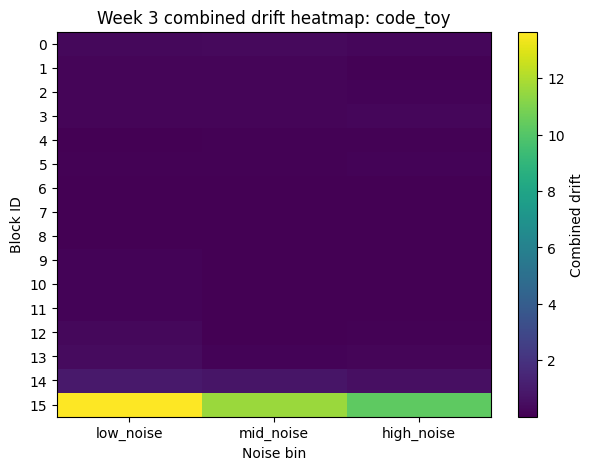

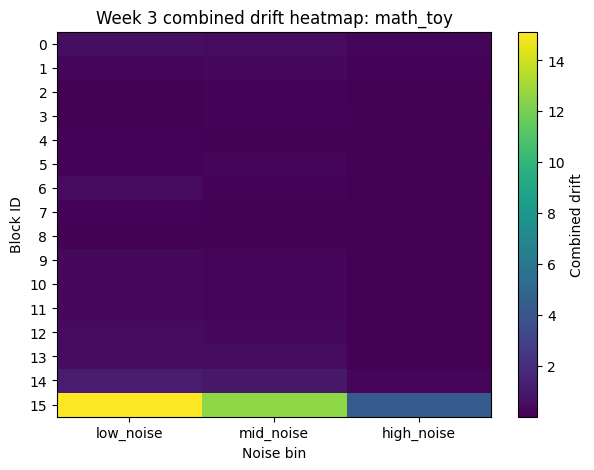

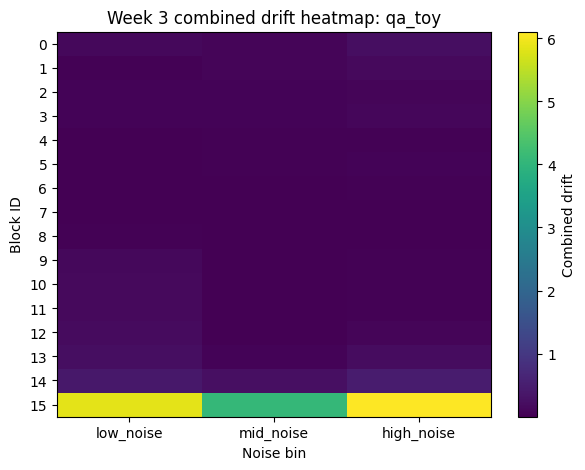

In [11]:
def normalize_series(s):
    s = s.astype(float)
    mn, mx = s.min(), s.max()
    if not np.isfinite(mn) or not np.isfinite(mx) or abs(mx - mn) < 1e-12:
        return s * 0.0
    return (s - mn) / (mx - mn)

ranking_base = (
    drift_df
    .groupby(["domain", "block_id"])
    .agg(
        mean_hidden_drift=("hidden_drift", "mean"),
        mean_layer_logit_kl=("layer_logit_kl", "mean"),
        mean_full_logit_kl=("full_logit_kl", "mean"),
    )
    .reset_index()
)

ranking_rows = []
for domain_name, sub in ranking_base.groupby("domain"):
    sub = sub.copy()
    sub["hidden_norm"] = normalize_series(sub["mean_hidden_drift"])
    sub["logit_norm"] = normalize_series(sub["mean_layer_logit_kl"])
    sub["combined_score"] = sub["hidden_norm"] + sub["logit_norm"]
    ranking_rows.append(sub)

ranking_df = pd.concat(ranking_rows, ignore_index=True)
ranking_path = OUT_DIR / "week3_layer_ranking_by_domain.csv"
ranking_df.to_csv(ranking_path, index=False)

print("Saved:", ranking_path)
display(ranking_df.head())

# Save heatmap values for hidden drift and logit KL.
for metric in ["hidden_drift", "layer_logit_kl", "combined_drift"]:
    heatmap = drift_df.pivot_table(
        index=["domain", "block_id"],
        columns="noise_bin",
        values=metric,
        aggfunc="mean",
    ).reset_index()
    path = OUT_DIR / f"week3_{metric}_heatmap_values.csv"
    heatmap.to_csv(path, index=False)
    print("Saved:", path)

# Plot combined heatmap per domain.
for domain_name in drift_df["domain"].unique():
    sub = drift_df[drift_df["domain"] == domain_name]
    pivot = sub.pivot_table(index="block_id", columns="noise_bin", values="combined_drift", aggfunc="mean")
    pivot = pivot[["low_noise", "mid_noise", "high_noise"]]
    plt.figure(figsize=(7, 5))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label="Combined drift")
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xlabel("Noise bin")
    plt.ylabel("Block ID")
    plt.title(f"Week 3 combined drift heatmap: {domain_name}")
    plt.show()

## 11. Select layers by rule and budget

In [12]:
def top_m_from_budget(num_blocks, budget):
    return max(1, int(math.ceil(num_blocks * budget)))


def select_layers(domain_name, rule, budget):
    m = top_m_from_budget(NUM_BLOCKS, budget)
    sub = ranking_df[ranking_df["domain"] == domain_name].copy()

    if rule == "combined":
        order = sub.sort_values("combined_score", ascending=False)
        return order.head(m)["block_id"].astype(int).tolist()

    if rule == "hidden_only":
        order = sub.sort_values("hidden_norm", ascending=False)
        return order.head(m)["block_id"].astype(int).tolist()

    if rule == "logit_only":
        order = sub.sort_values("logit_norm", ascending=False)
        return order.head(m)["block_id"].astype(int).tolist()

    if rule == "fixed_late":
        return sorted(all_layers)[-m:]

    if rule == "random":
        rng = random.Random(SEED + int(100 * budget) + len(domain_name))
        return sorted(rng.sample(list(all_layers), m))

    raise ValueError(rule)

SELECTION_RULES = ["combined", "hidden_only", "logit_only", "fixed_late", "random"]

selection_rows = []
for domain_name in DOMAINS:
    for budget in BUDGETS:
        for rule in SELECTION_RULES:
            layers = select_layers(domain_name, rule, budget)
            selection_rows.append({
                "domain": domain_name,
                "budget": budget,
                "rule": rule,
                "top_m": len(layers),
                "selected_layers": layers,
            })

selection_df = pd.DataFrame(selection_rows)
selection_path = OUT_DIR / "week3_selected_layers_by_rule_budget.csv"
selection_df.to_csv(selection_path, index=False)
print("Saved:", selection_path)
display(selection_df.head(20))

Saved: /content/week3_dasg_budget_sweeps/week3_selected_layers_by_rule_budget.csv


,domain,budget,rule,top_m,selected_layers
0,code_toy,0.25,combined,4,"[0, 15, 3, 2]"
1,code_toy,0.25,hidden_only,4,"[15, 14, 13, 12]"
2,code_toy,0.25,logit_only,4,"[0, 3, 2, 1]"
3,code_toy,0.25,fixed_late,4,"[12, 13, 14, 15]"
4,code_toy,0.25,random,4,"[6, 7, 9, 14]"
5,code_toy,0.33,combined,6,"[0, 15, 3, 2, 1, 5]"
6,code_toy,0.33,hidden_only,6,"[15, 14, 13, 12, 11, 10]"
7,code_toy,0.33,logit_only,6,"[0, 3, 2, 1, 5, 4]"
8,code_toy,0.33,fixed_late,6,"[10, 11, 12, 13, 14, 15]"
9,code_toy,0.33,random,6,"[1, 2, 7, 13, 14, 15]"


## 12. Sweep training/evaluation helpers

Each sweep run trains minimal DG+LoRA on selected layers and evaluates target-vs-retention tradeoff.

In [13]:
SWEEP_LEAVES = {"q_proj", "v_proj"}


def compute_retention_kl(model, text, noise_bin):
    mask_prob = NOISE_BINS[noise_bin]
    set_noise_bin(model, noise_bin)
    input_ids, attention_mask = encode_text(text, model)
    noisy_ids, masked_indices = make_masked_input(input_ids, attention_mask, mask_prob)

    with torch.no_grad():
        with disable_adapters(model):
            teacher_logits = forward_logits(model, noisy_ids).float()

    student_logits = forward_logits(model, noisy_ids).float()
    if masked_indices.sum().item() == 0:
        return torch.tensor(0.0, device=get_input_device(model)), 0

    teacher_log_probs = F.log_softmax(teacher_logits[masked_indices], dim=-1)
    student_log_probs = F.log_softmax(student_logits[masked_indices], dim=-1)
    teacher_probs = teacher_log_probs.exp()
    kl = F.kl_div(student_log_probs, teacher_probs, reduction="batchmean") / mask_prob
    return kl, int(masked_indices.sum().item())


def train_sweep_model(model, domain_name, texts, rule, budget, selected_layers):
    model.train()
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)
    rows = []

    for step in range(SWEEP_TRAIN_STEPS):
        noise_bin = random.choice(list(NOISE_BINS.keys()))
        target_text = random.choice(texts)
        retention_text = random.choice(RETENTION_TEXTS)

        if torch.cuda.is_available():
            torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
        start = time.time()

        target_loss, target_ce, target_masked = compute_domain_target_loss(model, target_text, noise_bin)
        retention_kl, retention_masked = compute_retention_kl(model, retention_text, noise_bin)
        gate_reg = gate_regularizer_tensor(model)

        total_loss = target_loss + LAMBDA_RET * retention_kl + BETA_GATE * gate_reg
        optimizer.zero_grad(); total_loss.backward(); optimizer.step()

        gm = collect_gate_metrics(model)
        row = {
            "domain": domain_name,
            "rule": rule,
            "budget": budget,
            "selected_layers": str(selected_layers),
            "step": step,
            "noise_bin": noise_bin,
            "target_ce_loss": float(target_ce.detach().cpu()),
            "target_weighted_loss": float(target_loss.detach().cpu()),
            "retention_kl_loss": float(retention_kl.detach().cpu()),
            "gate_regularizer": float(gate_reg.detach().cpu()),
            "total_loss": float(total_loss.detach().cpu()),
            "target_masked_tokens": target_masked,
            "retention_masked_tokens": retention_masked,
            "gate_entropy": gm["gate_entropy"],
            "frozen_branch_usage": gm["frozen_branch_usage"],
            "trainable_branch_usage": gm["trainable_branch_usage"],
            "trainable_params": count_trainable_params(model),
            "peak_gpu_memory_gb": gpu_mem_gb(),
            "elapsed_sec": time.time() - start,
        }
        rows.append(row)
        print(row)
    return rows


@torch.no_grad()
def eval_sweep_model(model, domain_name, texts, rule, budget, selected_layers, phase):
    model.eval()
    rows = []
    eval_sets = [("target", texts), ("retention", RETENTION_TEXTS)]

    for eval_domain, eval_texts in eval_sets:
        for text in eval_texts:
            for noise_bin, mask_prob in NOISE_BINS.items():
                set_noise_bin(model, noise_bin)
                input_ids, attention_mask = encode_text(text, model)
                noisy_ids, masked_indices = make_masked_input(input_ids, attention_mask, mask_prob)

                if torch.cuda.is_available():
                    torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
                start = time.time()

                student_logits = forward_logits(model, noisy_ids).float()
                with disable_adapters(model):
                    teacher_logits = forward_logits(model, noisy_ids).float()

                weighted, ce = masked_weighted_ce(student_logits, input_ids, masked_indices, mask_prob)
                teacher_weighted, teacher_ce = masked_weighted_ce(teacher_logits, input_ids, masked_indices, mask_prob)
                agree = teacher_agreement(student_logits, teacher_logits, masked_indices)
                gm = collect_gate_metrics(model)

                rows.append({
                    "domain": domain_name,
                    "eval_domain": eval_domain,
                    "rule": rule,
                    "budget": budget,
                    "selected_layers": str(selected_layers),
                    "phase": phase,
                    "text": text,
                    "noise_bin": noise_bin,
                    "mask_prob": mask_prob,
                    "ce_loss": float(ce.detach().cpu()),
                    "weighted_loss": float(weighted.detach().cpu()),
                    "teacher_weighted_loss": float(teacher_weighted.detach().cpu()),
                    "forgetting_vs_pretrained": float((weighted - teacher_weighted).detach().cpu()),
                    "teacher_agreement": agree,
                    "masked_tokens": int(masked_indices.sum().item()),
                    "gate_entropy": gm["gate_entropy"],
                    "frozen_branch_usage": gm["frozen_branch_usage"],
                    "trainable_branch_usage": gm["trainable_branch_usage"],
                    "trainable_params": count_trainable_params(model),
                    "peak_gpu_memory_gb": gpu_mem_gb(),
                    "elapsed_sec": time.time() - start,
                })
    return rows

## 13. Run Week 3 DASG budget sweeps

This runs: domains × budgets × rules.

If Colab is slow, stop the cell and set `FAST_DEBUG=True` in the config, or reduce `SWEEP_TRAIN_STEPS` to 1.

In [15]:
all_sweep_train_rows = []
all_sweep_eval_rows = []
all_sweep_meta = []

for _, row in selection_df.iterrows():
    domain_name = row["domain"]
    budget = float(row["budget"])
    rule = row["rule"]
    selected_layers = list(row["selected_layers"])
    texts = DOMAINS[domain_name]

    print("=" * 100)
    print("Sweep:", domain_name, rule, budget, selected_layers)

    cleanup_model()
    model = load_base_model()
    target_modules, _ = attach_dg_lora(
        model,
        selected_layers=selected_layers,
        leaves=SWEEP_LEAVES,
        gate_mode="dg",
    )

    all_sweep_meta.append({
        "domain": domain_name,
        "rule": rule,
        "budget": budget,
        "selected_layers": selected_layers,
        "num_target_modules": len(target_modules),
        "target_modules_sample": target_modules[:10],
        "trainable_params": count_trainable_params(model),
    })

    before_rows = eval_sweep_model(model, domain_name, texts, rule, budget, selected_layers, phase="before")
    train_rows = train_sweep_model(model, domain_name, texts, rule, budget, selected_layers)
    after_rows = eval_sweep_model(model, domain_name, texts, rule, budget, selected_layers, phase="after")

    all_sweep_eval_rows.extend(before_rows)
    all_sweep_train_rows.extend(train_rows)
    all_sweep_eval_rows.extend(after_rows)

    pd.DataFrame(all_sweep_eval_rows).to_csv(OUT_DIR / "week3_sweep_eval_partial.csv", index=False)
    pd.DataFrame(all_sweep_train_rows).to_csv(OUT_DIR / "week3_sweep_train_partial.csv", index=False)

    cleanup_model()

sweep_eval_df = pd.DataFrame(all_sweep_eval_rows)
sweep_train_df = pd.DataFrame(all_sweep_train_rows)

sweep_eval_path = OUT_DIR / "week3_sweep_eval_log.csv"
sweep_train_path = OUT_DIR / "week3_sweep_train_log.csv"
sweep_meta_path = OUT_DIR / "week3_sweep_meta.json"

sweep_eval_df.to_csv(sweep_eval_path, index=False)
sweep_train_df.to_csv(sweep_train_path, index=False)
with open(sweep_meta_path, "w") as f:
    json.dump(all_sweep_meta, f, indent=2)

print("Saved:", sweep_eval_path)
print("Saved:", sweep_train_path)
print("Saved:", sweep_meta_path)
display(sweep_eval_df.head())

Sweep: code_toy combined 0.25 [0, 15, 3, 2]


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


{'domain': 'code_toy', 'rule': 'combined', 'budget': 0.25, 'selected_layers': '[0, 15, 3, 2]', 'step': 0, 'noise_bin': 'high_noise', 'target_ce_loss': 5.440340995788574, 'target_weighted_loss': 6.400401592254639, 'retention_kl_loss': 0.10984879732131958, 'gate_regularizer': 0.12692800164222717, 'total_loss': 6.461672306060791, 'target_masked_tokens': 10, 'retention_masked_tokens': 12, 'gate_entropy': 0.36529266834259033, 'frozen_branch_usage': 0.8808176517486572, 'trainable_branch_usage': 0.11918234080076218, 'trainable_params': 131096, 'peak_gpu_memory_gb': 6.048033714294434, 'elapsed_sec': 5.121250152587891}
{'domain': 'code_toy', 'rule': 'combined', 'budget': 0.25, 'selected_layers': '[0, 15, 3, 2]', 'step': 1, 'noise_bin': 'high_noise', 'target_ce_loss': 3.588735580444336, 'target_weighted_loss': 4.222042083740234, 'retention_kl_loss': 1.3317112922668457, 'gate_regularizer': 0.1269046515226364, 'total_loss': 4.894242763519287, 'target_masked_tokens': 8, 'retention_masked_tokens': 6

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

...

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

{'domain': 'qa_toy', 'rule': 'fixed_late', 'budget': 0.5, 'selected_layers': '[8, 9, 10, 11, 12, 13, 14, 15]', 'step': 0, 'noise_bin': 'mid_noise', 'target_ce_loss': 0.9598236083984375, 'target_weighted_loss': 1.919647216796875, 'retention_kl_loss': 0.0011549086775630713, 'gate_regularizer': 0.31326165795326233, 'total_loss': 1.9358876943588257, 'target_masked_tokens': 8, 'retention_masked_tokens': 4, 'gate_entropy': 0.5821641683578491, 'frozen_branch_usage': 0.7310975193977356, 'trainable_branch_usage': 0.2689024806022644, 'trainable_params': 262192, 'peak_gpu_memory_gb': 5.979757785797119, 'elapsed_sec': 3.494375228881836}
{'domain': 'qa_toy', 'rule': 'fixed_late', 'budget': 0.5, 'selected_layers': '[8, 9, 10, 11, 12, 13, 14, 15]', 'step': 1, 'noise_bin': 'mid_noise', 'target_ce_loss': 4.6459550857543945, 'target_weighted_loss': 9.291910171508789, 'retention_kl_loss': 2.0311174012022093e-05, 'gate_regularizer': 0.3132084310054779, 'total_loss': 9.307580947875977, 'target_masked_token

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

{'domain': 'qa_toy', 'rule': 'random', 'budget': 0.5, 'selected_layers': '[0, 5, 6, 7, 9, 11, 12, 13]', 'step': 0, 'noise_bin': 'mid_noise', 'target_ce_loss': 2.189044237136841, 'target_weighted_loss': 4.378088474273682, 'retention_kl_loss': 0.10723131150007248, 'gate_regularizer': 0.31326165795326233, 'total_loss': 4.447367191314697, 'target_masked_tokens': 8, 'retention_masked_tokens': 6, 'gate_entropy': 0.5821641683578491, 'frozen_branch_usage': 0.7310975193977356, 'trainable_branch_usage': 0.2689024806022644, 'trainable_params': 262192, 'peak_gpu_memory_gb': 6.040165424346924, 'elapsed_sec': 4.783849239349365}
{'domain': 'qa_toy', 'rule': 'random', 'budget': 0.5, 'selected_layers': '[0, 5, 6, 7, 9, 11, 12, 13]', 'step': 1, 'noise_bin': 'mid_noise', 'target_ce_loss': 1.8914541006088257, 'target_weighted_loss': 3.7829082012176514, 'retention_kl_loss': 0.09429602324962616, 'gate_regularizer': 0.3132084310054779, 'total_loss': 3.845716714859009, 'target_masked_tokens': 6, 'retention_ma

,domain,eval_domain,rule,budget,selected_layers,phase,text,noise_bin,mask_prob,ce_loss,...,teacher_weighted_loss,forgetting_vs_pretrained,teacher_agreement,masked_tokens,gate_entropy,frozen_branch_usage,trainable_branch_usage,trainable_params,peak_gpu_memory_gb,elapsed_sec
0,code_toy,target,combined,0.25,"[0, 15, 3, 2]",before,"def add_numbers(a, b): return a + b",low_noise,0.15,1.242595,...,8.283967,0.0,1.0,2,0.662847,0.622459,0.377541,131096,5.934964,2.307022
1,code_toy,target,combined,0.25,"[0, 15, 3, 2]",before,"def add_numbers(a, b): return a + b",mid_noise,0.50,2.268871,...,4.537742,0.0,1.0,4,0.582203,0.731059,0.268941,131096,5.941407,1.674114
2,code_toy,target,combined,0.25,"[0, 15, 3, 2]",before,"def add_numbers(a, b): return a + b",high_noise,0.85,3.818017,...,4.491785,0.0,1.0,9,0.365334,0.880797,0.119203,131096,5.942286,1.687351
3,code_toy,target,combined,0.25,"[0, 15, 3, 2]",before,for i in range(n): total += arr[i],low_noise,0.15,1.686046,...,11.240303,0.0,1.0,2,0.662847,0.622459,0.377541,131096,5.941407,1.700787
4,code_toy,target,combined,0.25,"[0, 15, 3, 2]",before,for i in range(n): total += arr[i],mid_noise,0.50,1.948118,...,3.896235,0.0,1.0,4,0.582203,0.731059,0.268941,131096,5.941407,1.642776


## 14. Summarize before/after target and retention tradeoff

In [16]:
summary = (
    sweep_eval_df
    .groupby(["domain", "rule", "budget", "selected_layers", "eval_domain", "phase"])
    .agg(
        mean_weighted_loss=("weighted_loss", "mean"),
        mean_forgetting_vs_pretrained=("forgetting_vs_pretrained", "mean"),
        mean_teacher_agreement=("teacher_agreement", "mean"),
        mean_gate_entropy=("gate_entropy", "mean"),
        mean_frozen_branch_usage=("frozen_branch_usage", "mean"),
        mean_trainable_branch_usage=("trainable_branch_usage", "mean"),
        max_gpu_memory_gb=("peak_gpu_memory_gb", "max"),
        trainable_params=("trainable_params", "max"),
    )
    .reset_index()
)

summary_path = OUT_DIR / "week3_sweep_summary_by_phase.csv"
summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)
display(summary.head())

pivot = summary.pivot_table(
    index=["domain", "rule", "budget", "selected_layers", "eval_domain"],
    columns="phase",
    values="mean_weighted_loss",
).reset_index()

pivot["loss_change_after_minus_before"] = pivot["after"] - pivot["before"]
loss_change_path = OUT_DIR / "week3_before_after_loss_change.csv"
pivot.to_csv(loss_change_path, index=False)
print("Saved:", loss_change_path)
display(pivot.head())

# Target improvement and retention change in one table.
target_rows = pivot[pivot["eval_domain"] == "target"].copy()
ret_rows = pivot[pivot["eval_domain"] == "retention"].copy()
proxy = target_rows.merge(
    ret_rows,
    on=["domain", "rule", "budget", "selected_layers"],
    suffixes=("_target", "_retention"),
)

proxy = proxy[[
    "domain", "rule", "budget", "selected_layers",
    "loss_change_after_minus_before_target",
    "loss_change_after_minus_before_retention",
]]

# Score: prefer target loss drop, penalize retention loss increase.
proxy["week3_score"] = (
    -proxy["loss_change_after_minus_before_target"]
    - 0.5 * np.maximum(proxy["loss_change_after_minus_before_retention"], 0.0)
)

proxy = proxy.sort_values(["domain", "week3_score"], ascending=[True, False])
proxy_path = OUT_DIR / "week3_proxy_budget_pareto_table.csv"
proxy.to_csv(proxy_path, index=False)
print("Saved:", proxy_path)
display(proxy.head(20))

Saved: /content/week3_dasg_budget_sweeps/week3_sweep_summary_by_phase.csv


,domain,rule,budget,selected_layers,eval_domain,phase,mean_weighted_loss,mean_forgetting_vs_pretrained,mean_teacher_agreement,mean_gate_entropy,mean_frozen_branch_usage,mean_trainable_branch_usage,max_gpu_memory_gb,trainable_params
0,code_toy,combined,0.25,"[0, 15, 3, 2]",retention,after,9.184292,0.067624,0.831650,0.536768,0.744785,0.255215,5.948634,131096
1,code_toy,combined,0.25,"[0, 15, 3, 2]",retention,before,12.770650,0.000000,1.000000,0.536795,0.744772,0.255228,5.950484,131096
2,code_toy,combined,0.25,"[0, 15, 3, 2]",target,after,7.867552,0.382365,0.824405,0.536768,0.744785,0.255215,5.943950,131096
3,code_toy,combined,0.25,"[0, 15, 3, 2]",target,before,7.839713,0.000000,1.000000,0.536795,0.744772,0.255228,5.943458,131096
4,code_toy,combined,0.33,"[0, 15, 3, 2, 1, 5]",retention,after,8.493929,-1.071372,0.576094,0.536769,0.744784,0.255216,5.948541,196644


Saved: /content/week3_dasg_budget_sweeps/week3_before_after_loss_change.csv


phase,domain,rule,budget,selected_layers,eval_domain,after,before,loss_change_after_minus_before
0,code_toy,combined,0.25,"[0, 15, 3, 2]",retention,9.184292,12.770650,-3.586358
1,code_toy,combined,0.25,"[0, 15, 3, 2]",target,7.867552,7.839713,0.027838
2,code_toy,combined,0.33,"[0, 15, 3, 2, 1, 5]",retention,8.493929,15.223209,-6.729281
3,code_toy,combined,0.33,"[0, 15, 3, 2, 1, 5]",target,8.739212,11.221042,-2.481830
4,code_toy,combined,0.50,"[0, 15, 3, 2, 1, 5, 4, 6]",retention,9.081448,8.873450,0.207997


Saved: /content/week3_dasg_budget_sweeps/week3_proxy_budget_pareto_table.csv


phase,domain,rule,budget,selected_layers,loss_change_after_minus_before_target,loss_change_after_minus_before_retention,week3_score
8,code_toy,hidden_only,0.50,"[15, 14, 13, 12, 11, 10, 9, 8]",-4.594304,-4.456221,4.594304
2,code_toy,combined,0.50,"[0, 15, 3, 2, 1, 5, 4, 6]",-3.360416,0.207997,3.256417
14,code_toy,random,0.50,"[2, 4, 5, 6, 7, 10, 12, 14]",-3.357196,0.933025,2.890683
1,code_toy,combined,0.33,"[0, 15, 3, 2, 1, 5]",-2.481830,-6.729281,2.481830
3,code_toy,fixed_late,0.25,"[12, 13, 14, 15]",-0.533490,-1.625205,0.533490
0,code_toy,combined,0.25,"[0, 15, 3, 2]",0.027838,-3.586358,-0.027838
13,code_toy,random,0.33,"[1, 2, 7, 13, 14, 15]",0.251313,-7.527952,-0.251313
12,code_toy,random,0.25,"[6, 7, 9, 14]",0.921379,-5.009546,-0.921379
10,code_toy,logit_only,0.33,"[0, 3, 2, 1, 5, 4]",0.158673,1.657499,-0.987422
6,code_toy,hidden_only,0.25,"[15, 14, 13, 12]",0.345972,1.634576,-1.163260


## 15. Best budget/rule and drift-component ablation

Saved: /content/week3_dasg_budget_sweeps/week3_best_by_domain.csv


phase,domain,rule,budget,selected_layers,loss_change_after_minus_before_target,loss_change_after_minus_before_retention,week3_score
0,code_toy,hidden_only,0.50,"[15, 14, 13, 12, 11, 10, 9, 8]",-4.594304,-4.456221,4.594304
1,qa_toy,random,0.50,"[0, 5, 6, 7, 9, 11, 12, 13]",-4.125528,-0.714978,4.125528
2,math_toy,logit_only,0.25,"[0, 1, 6, 5]",-3.678379,1.172602,3.092078


Saved: /content/week3_dasg_budget_sweeps/week3_ablation_selection_rules.csv


,rule,mean_score,mean_target_loss_change,mean_retention_loss_change
4,random,-0.315957,-0.052362,-1.706579
2,hidden_only,-0.432710,-0.139358,0.262273
0,combined,-0.500337,0.354367,-2.307561
3,logit_only,-0.809014,0.012979,0.809782
1,fixed_late,-0.999141,0.560075,-1.339337


Saved: /content/week3_dasg_budget_sweeps/week3_ablation_budgets.csv


,budget,mean_score,mean_target_loss_change,mean_retention_loss_change
2,0.50,0.416547,-0.835864,-0.559077
0,0.25,-0.997839,0.550835,-1.393785
1,0.33,-1.253004,0.726449,-0.615991


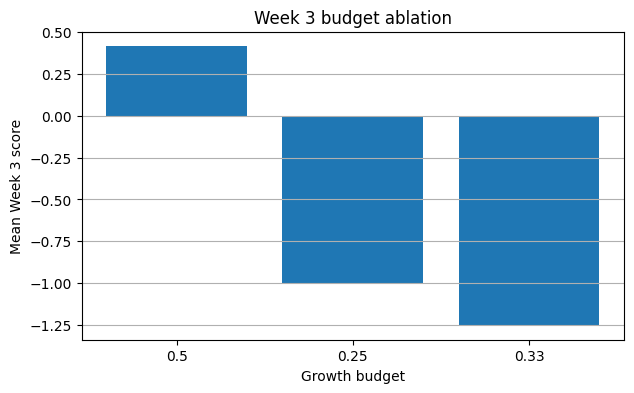

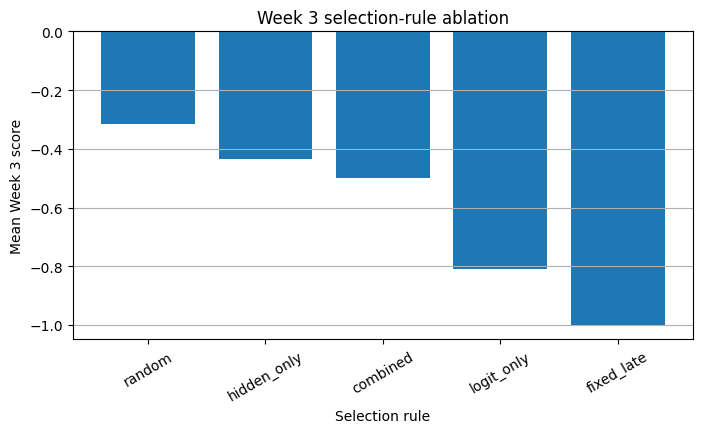

In [17]:
best_by_domain = proxy.sort_values("week3_score", ascending=False).groupby("domain").head(1).reset_index(drop=True)
best_by_domain_path = OUT_DIR / "week3_best_by_domain.csv"
best_by_domain.to_csv(best_by_domain_path, index=False)
print("Saved:", best_by_domain_path)
display(best_by_domain)

rule_ablation = (
    proxy
    .groupby("rule")
    .agg(
        mean_score=("week3_score", "mean"),
        mean_target_loss_change=("loss_change_after_minus_before_target", "mean"),
        mean_retention_loss_change=("loss_change_after_minus_before_retention", "mean"),
    )
    .reset_index()
    .sort_values("mean_score", ascending=False)
)
rule_ablation_path = OUT_DIR / "week3_ablation_selection_rules.csv"
rule_ablation.to_csv(rule_ablation_path, index=False)
print("Saved:", rule_ablation_path)
display(rule_ablation)

budget_ablation = (
    proxy
    .groupby("budget")
    .agg(
        mean_score=("week3_score", "mean"),
        mean_target_loss_change=("loss_change_after_minus_before_target", "mean"),
        mean_retention_loss_change=("loss_change_after_minus_before_retention", "mean"),
    )
    .reset_index()
    .sort_values("mean_score", ascending=False)
)
budget_ablation_path = OUT_DIR / "week3_ablation_budgets.csv"
budget_ablation.to_csv(budget_ablation_path, index=False)
print("Saved:", budget_ablation_path)
display(budget_ablation)

# Plot budget ablation.
plt.figure(figsize=(7, 4))
plt.bar(budget_ablation["budget"].astype(str), budget_ablation["mean_score"])
plt.xlabel("Growth budget")
plt.ylabel("Mean Week 3 score")
plt.title("Week 3 budget ablation")
plt.grid(axis="y")
plt.show()

# Plot rule ablation.
plt.figure(figsize=(8, 4))
plt.bar(rule_ablation["rule"], rule_ablation["mean_score"])
plt.xlabel("Selection rule")
plt.ylabel("Mean Week 3 score")
plt.title("Week 3 selection-rule ablation")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

## 16. Save internal note and reproducibility report

In [18]:
best_rule = rule_ablation.iloc[0]["rule"]
best_budget = float(budget_ablation.iloc[0]["budget"])

note = f"""# Week 3 Internal Note: DASG Sweeps

## Setup
- Model: {MODEL_NAME}
- Quantization: 4-bit NF4
- Domains: {', '.join(DOMAINS.keys())}
- Budgets tested: {BUDGETS}
- Selection rules tested: {SELECTION_RULES}
- Drift components: hidden-state drift, layerwise logit-KL attribution, and combined normalized drift.

## Best overall rule
The best average selection rule by proxy score was: **{best_rule}**.

## Best overall budget
The best average growth budget by proxy score was: **{best_budget}**.

## Interpretation
The proxy score rewards target-domain loss reduction and penalizes retention loss increase. Combined drift uses both hidden-state movement and layerwise logit-KL attribution, while the ablations isolate each component. If combined drift wins, it suggests that both internal representation drift and output-distribution drift are useful for DASG. If hidden-only wins, the hidden-state probe is the stronger signal. If logit-only wins, output attribution is the stronger signal.

## Limitation
This is a small Colab/T4 sweep on toy domains. It provides an internal selection rule and budget recommendation, but should be rerun on the final 170M/small LLaDA checkpoint and real domains when that checkpoint/data are available.
"""

note_path = OUT_DIR / "week3_internal_note.md"
with open(note_path, "w") as f:
    f.write(note)

report = {
    "week": 3,
    "task": "DASG sweeps for growth budget and selection-rule ablation",
    "model": MODEL_NAME,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "quantization": "4-bit NF4",
    "domains": list(DOMAINS.keys()),
    "budgets": BUDGETS,
    "selection_rules": SELECTION_RULES,
    "drift_components": ["hidden_state_drift", "layerwise_logit_kl", "combined_normalized_drift"],
    "best_rule": str(best_rule),
    "best_budget": best_budget,
    "outputs": {
        "probe_train_log": str(probe_train_path),
        "drift_scores": str(drift_path),
        "layer_ranking": str(ranking_path),
        "selected_layers": str(selection_path),
        "sweep_eval_log": str(sweep_eval_path),
        "sweep_train_log": str(sweep_train_path),
        "sweep_summary": str(summary_path),
        "loss_change": str(loss_change_path),
        "proxy_pareto": str(proxy_path),
        "best_by_domain": str(best_by_domain_path),
        "rule_ablation": str(rule_ablation_path),
        "budget_ablation": str(budget_ablation_path),
        "internal_note": str(note_path),
    },
    "limitation": "Small toy-domain Colab run; rerun on final 170M/small LLaDA checkpoint and real domains when available.",
}

report_path = OUT_DIR / "week3_reproducibility_report.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print("Saved:", note_path)
print("Saved:", report_path)
print(note)

Saved: /content/week3_dasg_budget_sweeps/week3_internal_note.md
Saved: /content/week3_dasg_budget_sweeps/week3_reproducibility_report.json
# Week 3 Internal Note: DASG Sweeps

## Setup
- Model: inclusionAI/LLaDA-MoE-7B-A1B-Instruct
- Quantization: 4-bit NF4
- Domains: code_toy, math_toy, qa_toy
- Budgets tested: [0.25, 0.33, 0.5]
- Selection rules tested: ['combined', 'hidden_only', 'logit_only', 'fixed_late', 'random']
- Drift components: hidden-state drift, layerwise logit-KL attribution, and combined normalized drift.

## Best overall rule
The best average selection rule by proxy score was: **random**.

## Best overall budget
The best average growth budget by proxy score was: **0.5**.

## Interpretation
The proxy score rewards target-domain loss reduction and penalizes retention loss increase. Combined drift uses both hidden-state movement and layerwise logit-KL attribution, while the ablations isolate each component. If combined drift wins, it suggests that both internal representa

In [19]:
from pathlib import Path

out_dir = Path("/content/week3_dasg_budget_sweeps")

expected_files = [
    "week3_drift_probe_train_log.csv",
    "week3_drift_scores.csv",
    "week3_layer_ranking_by_domain.csv",
    "week3_selected_layers_by_rule_budget.csv",
    "week3_sweep_eval_log.csv",
    "week3_sweep_train_log.csv",
    "week3_proxy_budget_pareto_table.csv",
    "week3_ablation_selection_rules.csv",
    "week3_ablation_budgets.csv",
    "week3_best_by_domain.csv",
    "week3_internal_note.md",
    "week3_reproducibility_report.json",
]

for f in expected_files:
    path = out_dir / f
    print(f, "FOUND" if path.exists() else "MISSING")

week3_drift_probe_train_log.csv FOUND
week3_drift_scores.csv FOUND
week3_layer_ranking_by_domain.csv FOUND
week3_selected_layers_by_rule_budget.csv FOUND
week3_sweep_eval_log.csv FOUND
week3_sweep_train_log.csv FOUND
week3_proxy_budget_pareto_table.csv FOUND
week3_ablation_selection_rules.csv FOUND
week3_ablation_budgets.csv FOUND
week3_best_by_domain.csv FOUND
week3_internal_note.md FOUND
week3_reproducibility_report.json FOUND


## 17. Expected outputs

After running the notebook, you should have:

```text
/content/week3_dasg_budget_sweeps/week3_drift_probe_train_log.csv
/content/week3_dasg_budget_sweeps/week3_drift_scores.csv
/content/week3_dasg_budget_sweeps/week3_layer_ranking_by_domain.csv
/content/week3_dasg_budget_sweeps/week3_selected_layers_by_rule_budget.csv
/content/week3_dasg_budget_sweeps/week3_sweep_eval_log.csv
/content/week3_dasg_budget_sweeps/week3_sweep_train_log.csv
/content/week3_dasg_budget_sweeps/week3_proxy_budget_pareto_table.csv
/content/week3_dasg_budget_sweeps/week3_ablation_selection_rules.csv
/content/week3_dasg_budget_sweeps/week3_ablation_budgets.csv
/content/week3_dasg_budget_sweeps/week3_best_by_domain.csv
/content/week3_dasg_budget_sweeps/week3_internal_note.md
/content/week3_dasg_budget_sweeps/week3_reproducibility_report.json
```
